In [1969]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1970]:
df = pd.read_csv('datasets/housing_train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [1971]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [1972]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

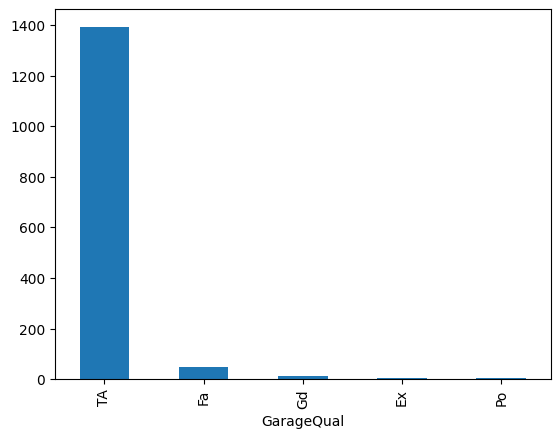

In [1992]:
df['GarageQual'].value_counts().plot.bar()

In [1981]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

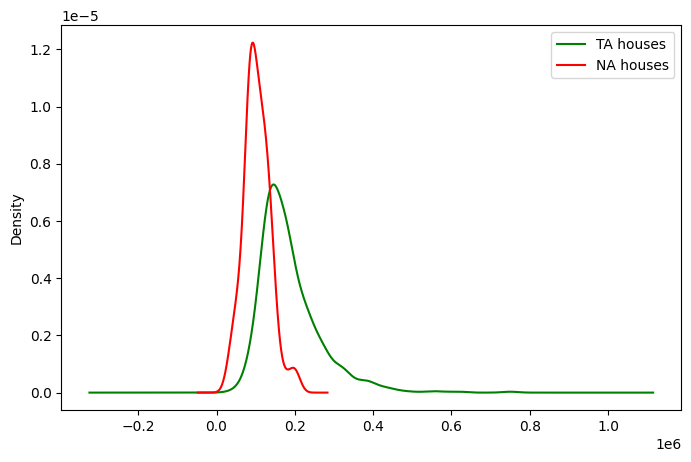

In [1987]:
fig, ax = plt.subplots(figsize=(8, 5))
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='green', label='TA houses')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red', label='NA houses')
ax.legend()
plt.show()

In [1988]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [1989]:
df['GarageQual'].fillna('TA', inplace=True)

<Axes: xlabel='GarageQual'>

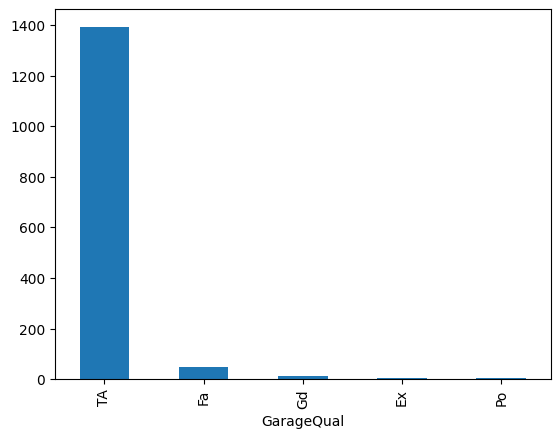

In [1993]:
df['GarageQual'].value_counts().plot.bar()

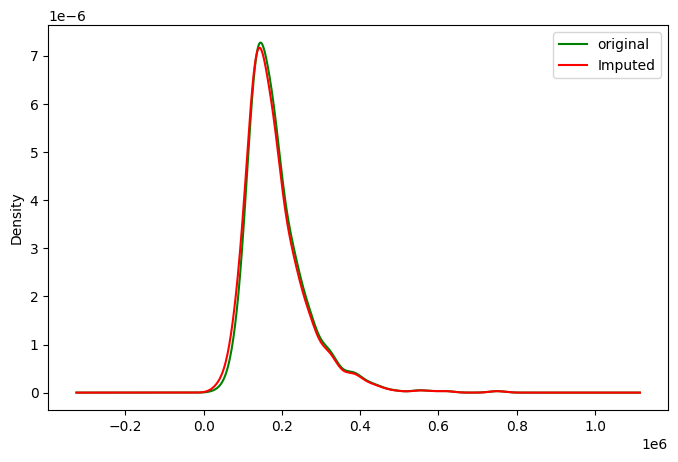

In [1997]:
fig, ax = plt.subplots(figsize=(8, 5))

temp.plot(kind='kde', ax=ax, color='green', label='original')

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red', label='Imputed')
ax.legend()
plt.show()

<Axes: xlabel='FireplaceQu'>

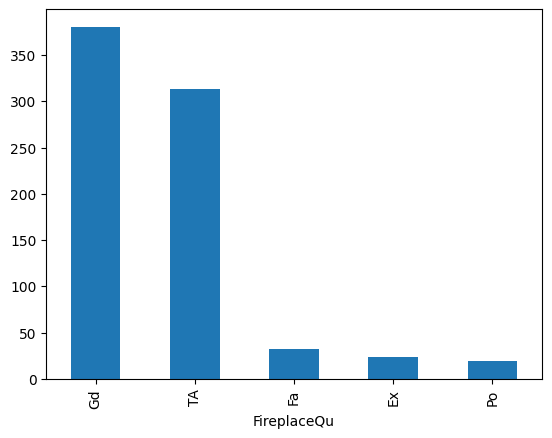

In [1998]:
df['FireplaceQu'].value_counts().plot.bar()

In [1999]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

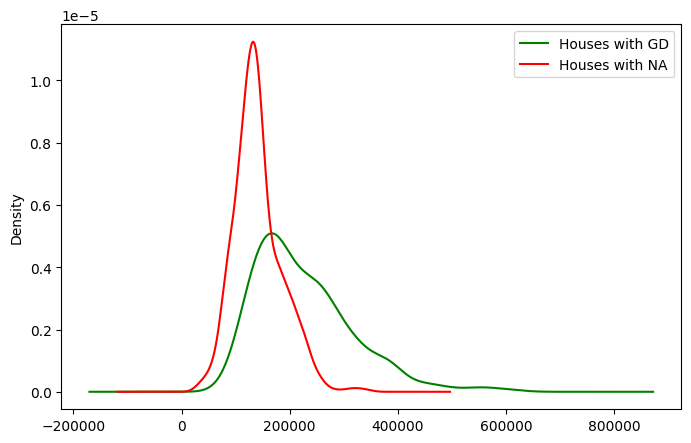

In [2002]:
fig, ax = plt.subplots(figsize=(8, 5)) 

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='Green' ,label='Houses with GD')

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red' ,label='Houses with NA')
ax.legend()
plt.show()

In [2003]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [2004]:
df['FireplaceQu'].fillna('Gd', inplace=True)

<Axes: xlabel='FireplaceQu'>

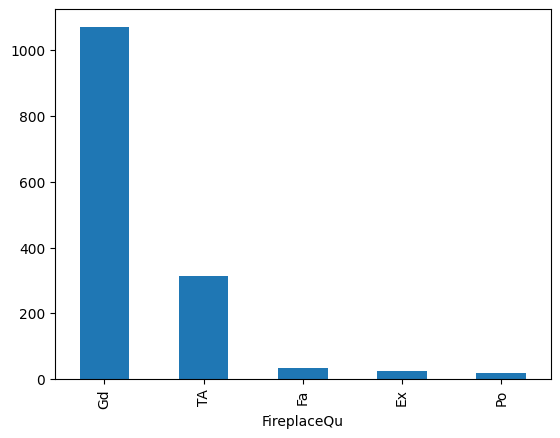

In [2005]:
df['FireplaceQu'].value_counts().plot.bar()

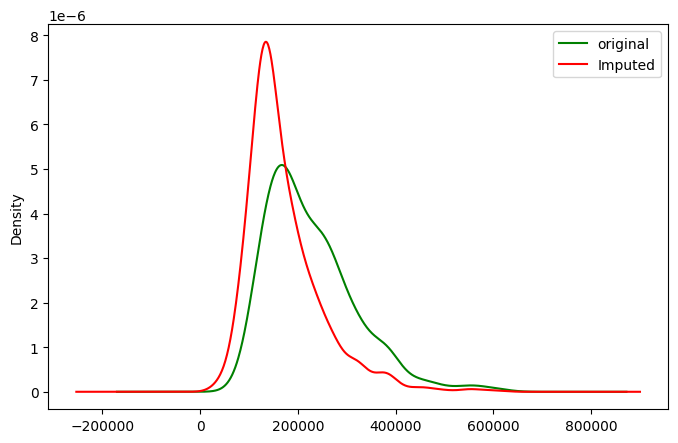

In [2006]:
fig, ax = plt.subplots(figsize=(8, 5))

temp.plot(kind='kde', color='green', label='original')

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red', label='Imputed')

ax.legend(loc='best')

plt.show()

In [2007]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [2008]:
from sklearn.impute import SimpleImputer

In [2013]:
imputer = SimpleImputer(strategy='constant', fill_value='missing')

In [2014]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

In [2015]:
imputer.statistics_

array(['missing', 'missing'], dtype=object)